This notebook transforms raw turbofan engine sensor data into a structured predictive modeling dataset by computing Remaining Useful Life (RUL), a key target variable for predictive maintenance systems.

This step bridges raw time-series data with machine learning and causal analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded")

Libraries loaded


In [9]:
from google.colab import files
uploaded = files.upload()

train_path = list(uploaded.keys())[0]

df = pd.read_csv(train_path, sep=r"\s+", header=None)

Saving train_FD001.txt to train_FD001.txt


In [10]:
columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1, 22):
    columns.append(f"sensor_{i}")

df.columns = columns

df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [17]:
df.shape
df.describe()

print("Total engines:", df["engine_id"].nunique())

Total engines: 100


In [12]:
engine_life = df.groupby("engine_id")["cycle"].max().reset_index()
engine_life.columns = ["engine_id", "max_cycle"]

engine_life.head()

,engine_id,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [20]:
df = df.merge(engine_life, on="engine_id")

df["RUL"] = df["max_cycle"] - df["cycle"]

print("RUL stats summary:")
print(df["RUL"].describe())

print("\nSample RUL values per engine:")
print(df.groupby("engine_id")["RUL"].head(3))



RUL stats summary:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

Sample RUL values per engine:
0        191
1        190
2        189
192      286
193      285
        ... 
20247    183
20248    182
20431    199
20432    198
20433    197
Name: RUL, Length: 300, dtype: int64


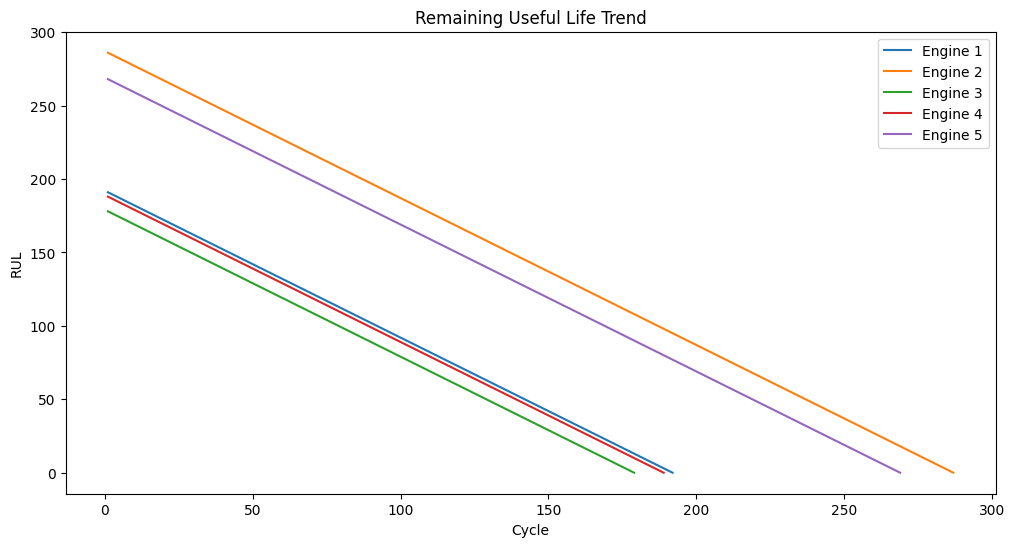

In [14]:
plt.figure(figsize=(12,6))

for i in range(1,6):
    temp = df[df["engine_id"] == i]
    plt.plot(temp["cycle"], temp["RUL"], label=f"Engine {i}")

plt.title("Remaining Useful Life Trend")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.legend()
plt.show()

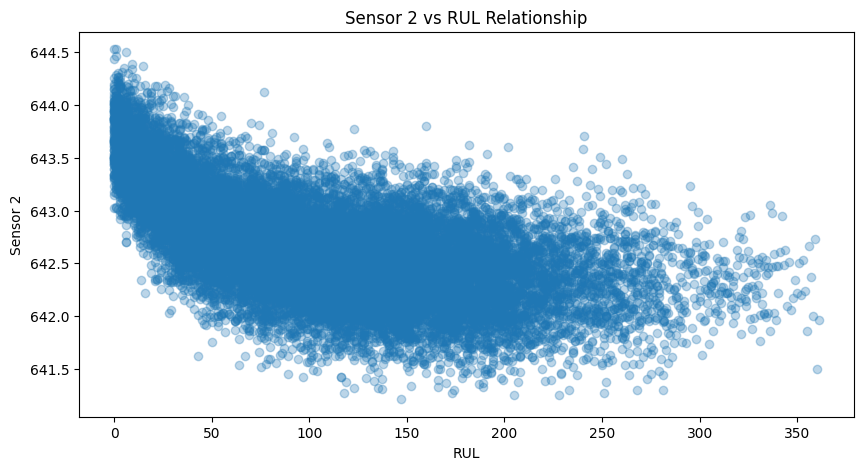

In [15]:
plt.figure(figsize=(10,5))

plt.scatter(df["RUL"], df["sensor_2"], alpha=0.3)

plt.title("Sensor 2 vs RUL Relationship")
plt.xlabel("RUL")
plt.ylabel("Sensor 2")
plt.show()

Correlation analysis is used here only for exploratory understanding.

It does not represent causal influence and will later be replaced with causal discovery methods.

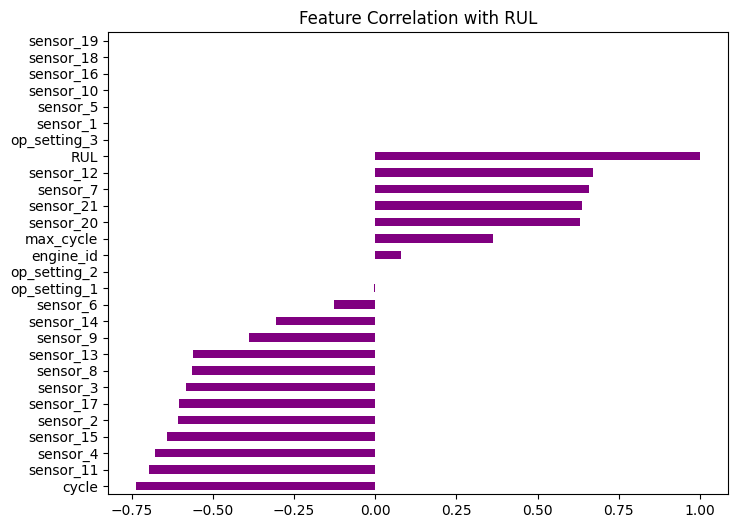

In [16]:
corr = df.corr()["RUL"].sort_values()

plt.figure(figsize=(8,6))
corr.plot(kind="barh", color="purple")
plt.title("Feature Correlation with RUL")
plt.show()

- RUL provides supervised learning target for failure prediction
- Sensor drift increases as RUL decreases
- Some sensors strongly correlate with degradation
- Operational settings introduce variability but not direct failure cause

This confirms the need for causal modeling beyond correlation.

This notebook transforms raw telemetry into a structured predictive maintenance dataset.

However, prediction alone is not sufficient.

Next step:
→ Causal Graph Construction
→ Dependency discovery between sensors
→ Transition from prediction to causation